In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv')
df.shape

(6362620, 11)

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.value_counts('isFlaggedFraud')

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [5]:
df.value_counts('newbalanceDest')

newbalanceDest
0.000000e+00    2439433
1.000000e+07         53
9.714189e+05         32
1.916920e+07         29
1.653203e+07         25
                 ...   
4.164953e+05          1
4.164963e+05          1
4.164965e+05          1
4.164967e+05          1
3.561793e+08          1
Name: count, Length: 3555499, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


<Axes: ylabel='count'>

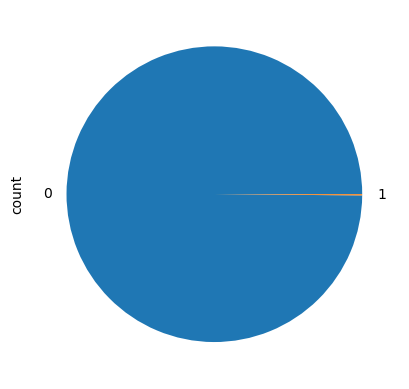

In [10]:
df['isFraud'].value_counts().plot.pie()

<Axes: ylabel='count'>

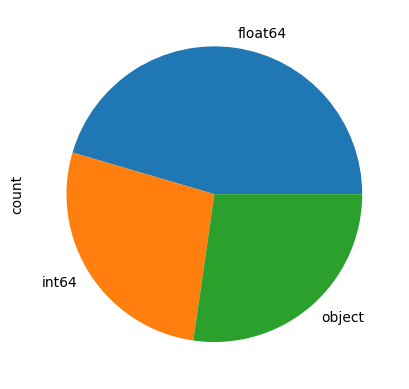

In [11]:
df.dtypes.value_counts().plot.pie()

In [12]:
taux_fraude = df['isFraud'].mean()*100
print(f"le taux de fraud:{taux_fraude}")

le taux de fraud:0.12908204481801522


In [13]:
df.groupby('type')['isFraud'].mean()*100

type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64

In [14]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [15]:
colonnes_numeriques = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for col in colonnes_numeriques:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    seuil_bas = Q1 - 1.5 * IQR
    seuil_haut = Q3 + 1.5 * IQR
    
    nb_anomalies = ((df[col] < seuil_bas) | (df[col] > seuil_haut)).sum()
    pct = nb_anomalies / len(df) * 100
    print(f"{col}: {nb_anomalies} anomalies ({pct:.2f}%)")

amount: 338078 anomalies (5.31%)
oldbalanceOrg: 1112507 anomalies (17.49%)
newbalanceOrig: 1053391 anomalies (16.56%)
oldbalanceDest: 786135 anomalies (12.36%)
newbalanceDest: 738527 anomalies (11.61%)


In [16]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
seuil_haut = Q3 + 1.5 * IQR

anomalies_amount = df[df['amount'] > seuil_haut]
print(f"Taux de fraude parmi les anomalies de montant : {anomalies_amount['isFraud'].mean() * 100:.2f}%")
print(f"Taux de fraude global (rappel) : {df['isFraud'].mean() * 100:.2f}%")

Taux de fraude parmi les anomalies de montant : 1.14%
Taux de fraude global (rappel) : 0.13%


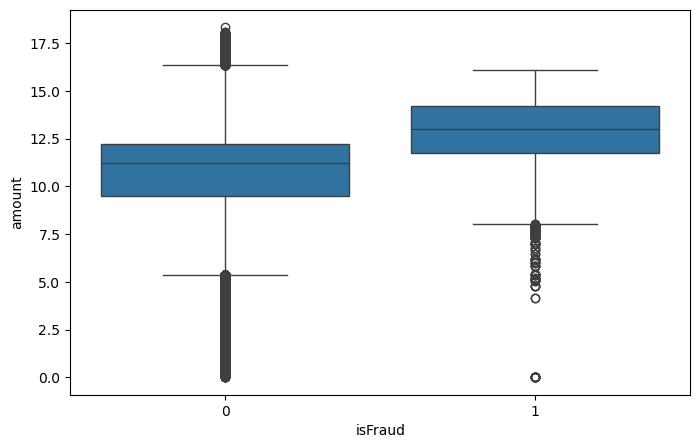

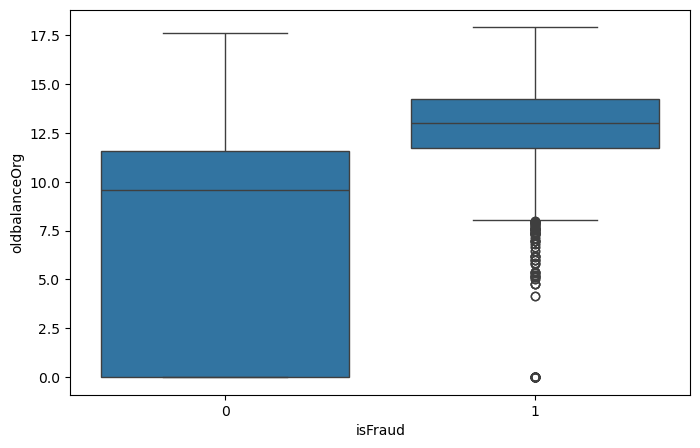

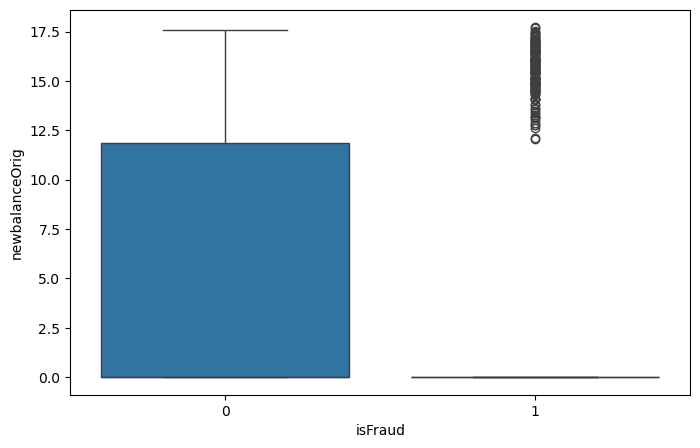

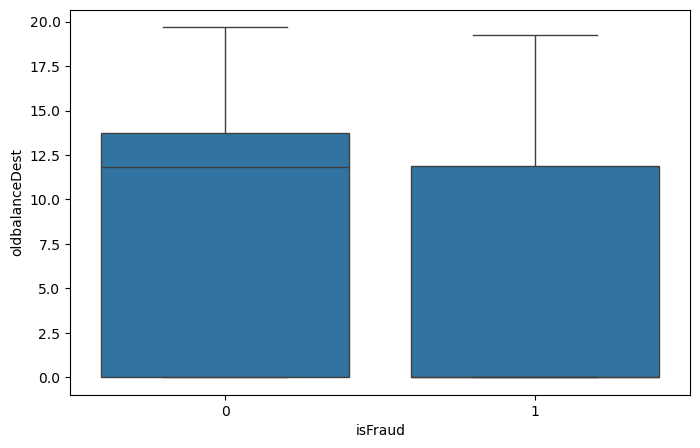

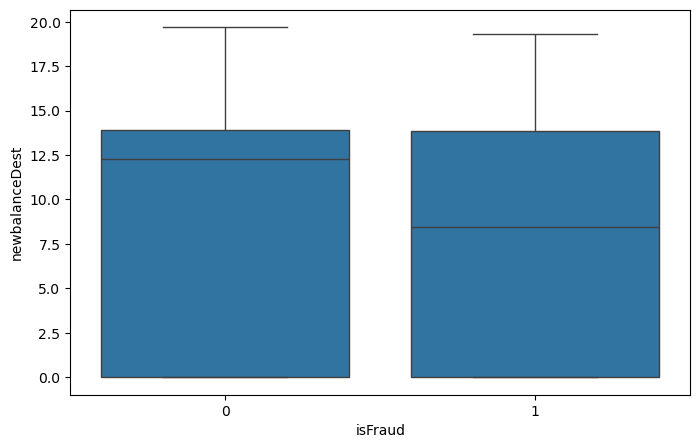

In [17]:

for col in colonnes_numeriques:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='isFraud', y=np.log1p(df[col]))

In [18]:
for col in colonnes_numeriques:
    print(f"{col}: skew = {df[col].skew():.2f}")

amount: skew = 30.99
oldbalanceOrg: skew = 5.25
newbalanceOrig: skew = 5.18
oldbalanceDest: skew = 19.92
newbalanceDest: skew = 19.35


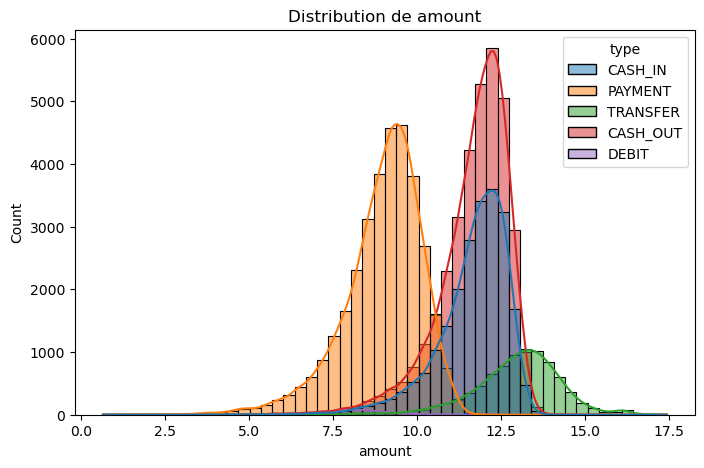

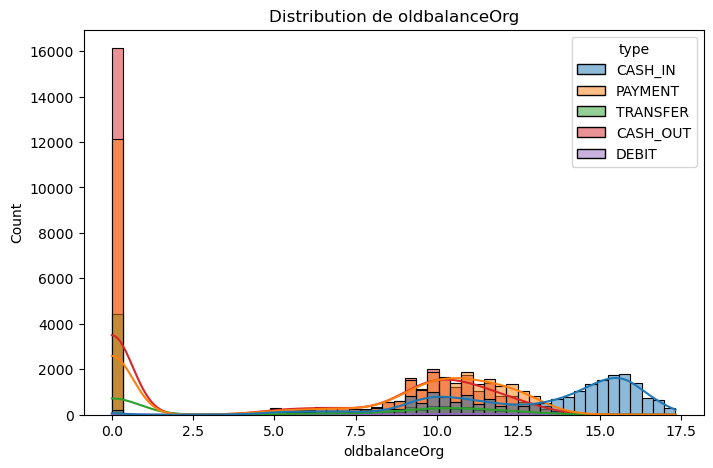

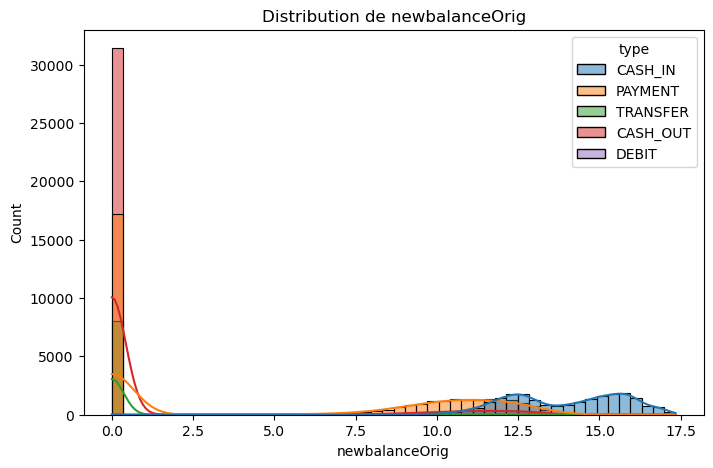

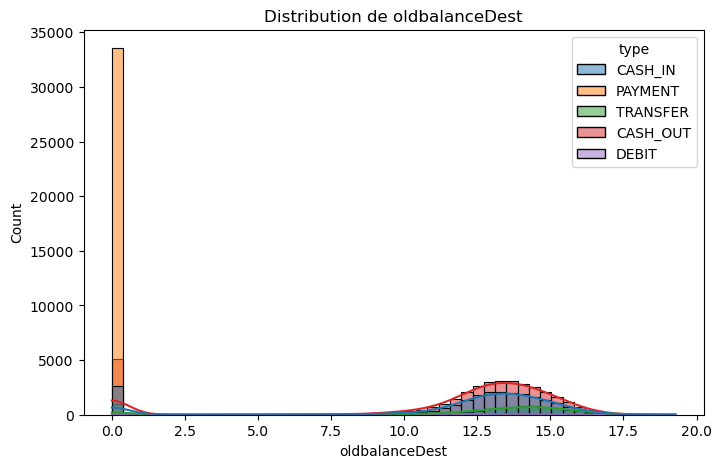

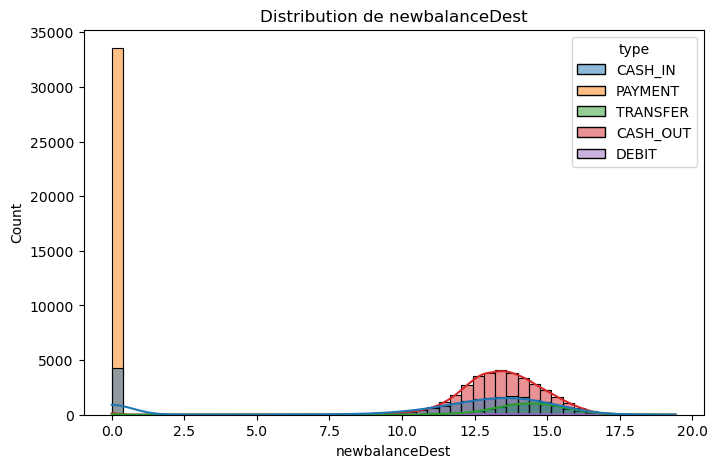

In [22]:
sample = df.sample(n=100000, random_state=42)

for col in colonnes_numeriques:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=sample, x=np.log1p(sample[col]),hue='type', bins=50, kde=True)
    plt.title(f'Distribution de {col}')
    plt.show()

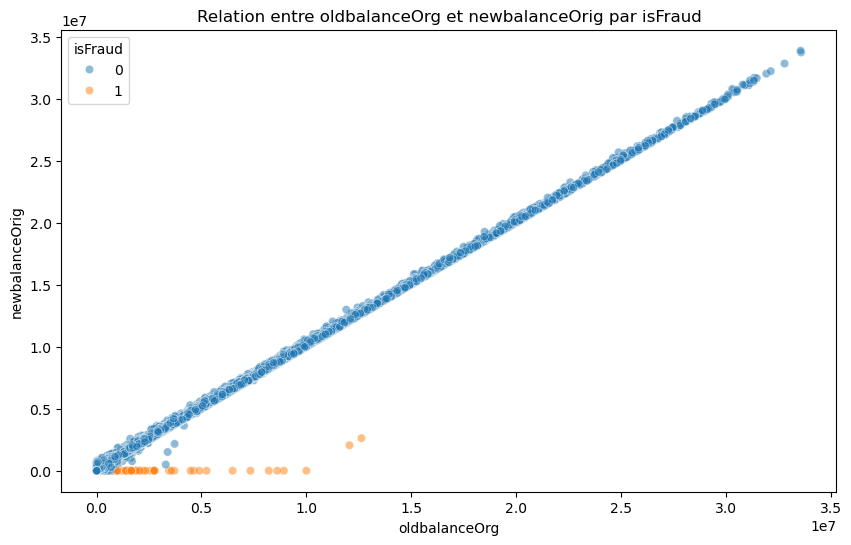

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x='oldbalanceOrg', y='newbalanceOrig', hue='isFraud', alpha=0.5)
plt.title('Relation entre oldbalanceOrg et newbalanceOrig par isFraud')
plt.show()

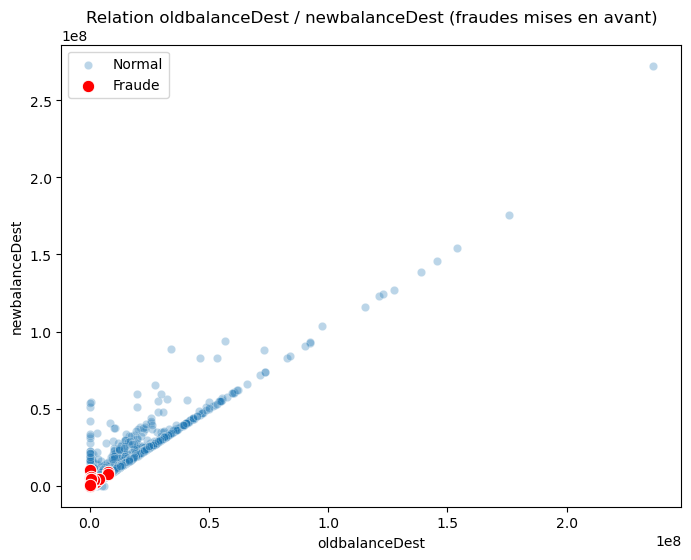

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample[sample['isFraud']==0], x='oldbalanceDest', y='newbalanceDest', alpha=0.3, label='Normal')
sns.scatterplot(data=sample[sample['isFraud']==1], x='oldbalanceDest', y='newbalanceDest', color='red', s=80, label='Fraude')
plt.title('Relation oldbalanceDest / newbalanceDest (fraudes mises en avant)')
plt.legend()
plt.show()

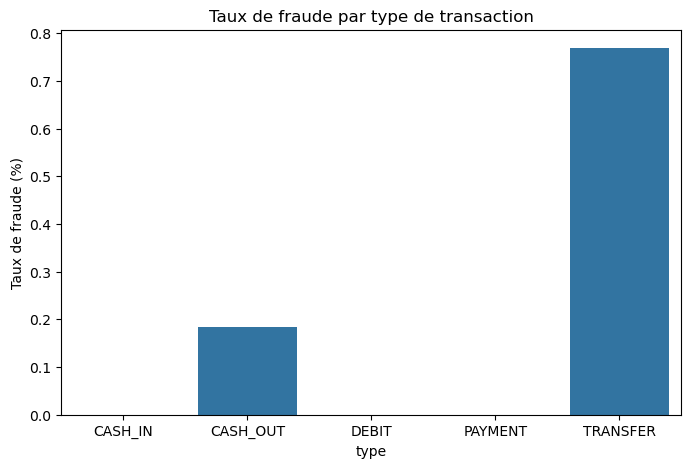

In [25]:
taux_fraude_par_type = df.groupby('type')['isFraud'].mean().reset_index()
taux_fraude_par_type['isFraud'] = taux_fraude_par_type['isFraud'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=taux_fraude_par_type, x='type', y='isFraud')
plt.ylabel('Taux de fraude (%)')
plt.title('Taux de fraude par type de transaction')
plt.show()

In [26]:
colonnes_a_analyser = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
                        'oldbalanceDest', 'newbalanceDest', 'isFraud']

correlation_matrix = df[colonnes_a_analyser].corr()
correlation_matrix

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


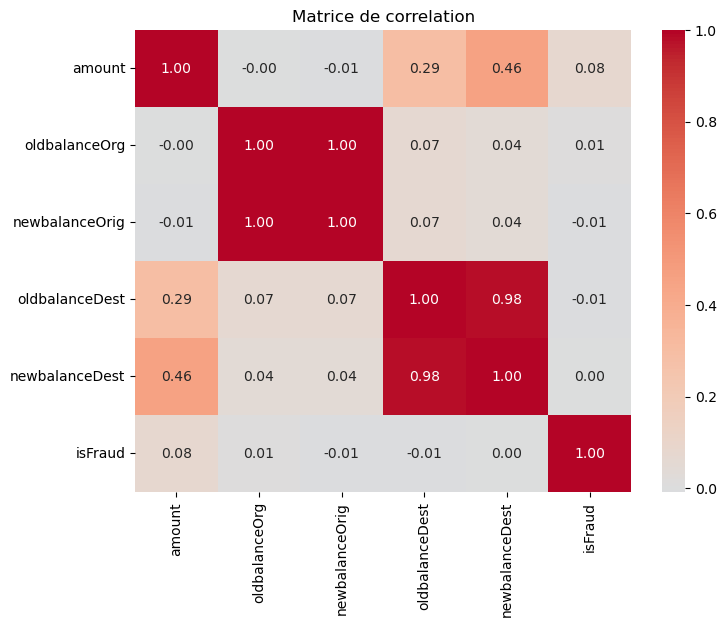

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de correlation')
plt.show()

In [28]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

df[['type', 'type_encoded']].drop_duplicates()

,type,type_encoded
0,PAYMENT,3
2,TRANSFER,4
3,CASH_OUT,1
9,DEBIT,2
389,CASH_IN,0


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['amount_scaled'] = scaler.fit_transform(df[['amount']])

df[['amount', 'amount_scaled']].describe()

,amount,amount_scaled
count,6.362620e+06,6.362620e+06
mean,1.798619e+05,-1.829676e-17
std,6.038582e+05,1.000000e+00
min,0.000000e+00,-2.978545e-01
25%,1.338957e+04,-2.756812e-01
50%,7.487194e+04,-1.738653e-01
75%,2.087215e+05,4.779197e-02
max,9.244552e+07,1.527936e+02


In [31]:
colonnes_a_normaliser = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for col in colonnes_a_normaliser:
    df[f'{col}_scaled'] = scaler.fit_transform(df[[col]])

df[[c + '_scaled' for c in colonnes_a_normaliser]].describe()

,oldbalanceOrg_scaled,newbalanceOrig_scaled,oldbalanceDest_scaled,newbalanceDest_scaled
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,-1.829676e-17,1.343668e-17,1.143547e-17,-6.861284e-18
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.887164e-01,-2.924417e-01,-3.238139e-01,-3.334114e-01
25%,-2.887164e-01,-2.924417e-01,-3.238139e-01,-3.334114e-01
50%,-2.837972e-01,-2.924417e-01,-2.847734e-01,-2.749863e-01
75%,-2.515606e-01,-2.431065e-01,-4.638324e-02,-3.077931e-02
max,2.034149e+01,1.666523e+01,1.044120e+02,9.660911e+01


In [32]:
df['origBalanceEmptied'] = (df['newbalanceOrig'] == 0).astype(int)

df.groupby('isFraud')['origBalanceEmptied'].mean() * 100

isFraud
0    56.677405
1    98.051869
Name: origBalanceEmptied, dtype: float64

In [34]:
df['hour_of_day'] = df['step'] % 24

df.groupby('hour_of_day')['isFraud'].mean() * 100

hour_of_day
0      0.419071
1      1.320497
2      4.125083
3     16.243149
4     22.078969
5     22.303473
6     10.467836
7      3.649310
8      1.367267
9      0.120275
10     0.088084
11     0.072647
12     0.070126
13     0.073857
14     0.080291
15     0.081836
16     0.078123
17     0.080238
18     0.059086
19     0.052793
20     0.061402
21     0.140029
22     0.180412
23     0.228661
Name: isFraud, dtype: float64

In [36]:
df['hour_of_day'].value_counts().sort_index()

hour_of_day
0      71587
1      27111
2       9018
3       2007
4       1241
5       1641
6       3420
7       8988
8      26915
9     283518
10    425729
11    445992
12    483418
13    468474
14    439653
15    416686
16    441612
17    439941
18    580509
19    647814
20    553728
21    247806
22    194555
23    141257
Name: count, dtype: int64

In [37]:
# Encodage
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

# Variables dérivées
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['origBalanceEmptied'] = (df['newbalanceOrig'] == 0).astype(int)
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['hour_of_day'] = df['step'] % 24

In [38]:
colonnes_finales = [
    'step', 'type_encoded', 'amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'origBalanceEmptied', 'errorBalanceDest',
    'hour_of_day',
    'isFraud'
]

df_final = df[colonnes_finales].copy()
df_final.shape

(6362620, 12)

In [ ]:
df_final.info()
df_final.isnull().sum()

In [ ]:
df_final.to_csv('../data/processed/paysim_final.csv', index=False)
print("Dataset final sauvegarde.")

**Section 1  Difficultés rencontrées**

La principale difficulté rencontrée a été l'interprétation des boxplots sur l'ensemble des variables financières du dataset (amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest). En parcourant systématiquement ces colonnes avec une boucle, les boxplots apparaissaient presque entièrement écrasés vers zéro, avec un très grand nombre de points marqués comme valeurs extrêmes.

Cette observation s'explique par la distribution fortement asymétrique à droite de ces variables : la grande majorité des transactions portent sur de petits montants, tandis qu'une minorité de transactions à valeurs très élevées oblige l'échelle des graphiques à s'étirer. Cela écrase visuellement la masse des transactions normales, qui se retrouvent toutes regroupées dans un espace minuscule du graphique.

Ce même phénomène explique le nombre élevé de valeurs jugées extrêmes par la méthode de détection d'anomalies IQR sur chacune de ces colonnes, jusqu'à 17,49% pour oldbalanceOrg et 16,56% pour newbalanceOrig. Le seuil de détection, calculé à partir d'une distribution concentrée sur de petites valeurs, reste bas, ce qui classe automatiquement toute transaction un peu plus élevée comme anomalie, même si elle reste parfaitement légitime.

La transformation logarithmique (log1p), appliquée systématiquement sur ces mêmes colonnes, a permis de rendre les distributions lisibles. Elle a même révélé une structure bimodale sur amount, c'est à dire deux groupes de montants distincts liés au type de transaction, les PAYMENT se concentrant sur des montants plus faibles, contre CASH_OUT et TRANSFER sur des montants plus élevés.

Cette transformation a toutefois été utilisée uniquement à des fins de visualisation exploratoire. Elle change la représentation graphique des données sans en modifier la réalité sous-jacente, et son usage éventuel pour l'entraînement du modèle mériterait une validation empirique séparée plutôt qu'une adoption automatique.

**Section 2 explication de choix des models**

Trois modèles sont prévus pour la suite du projet : Logistic Regression, Random Forest et XGBoost. La Logistic Regression servira de référence simple, permettant de vérifier si les modèles plus complexes apportent une réelle amélioration. Cependant, l'analyse de corrélation a montré une relation quasi nulle entre amount et isFraud malgré un lien réel observé dans l'exploration visuelle, ce qui indique que la relation entre les variables et la fraude n'est probablement pas linéaire mais repose plutôt sur des seuils et des combinaisons de conditions. Random Forest et XGBoost, en tant que modèles à base d'arbres, sont a priori mieux adaptés pour capter ce type de relation.

C'est pour cette raison que la normalisation StandardScaler a été appliquée aux variables numériques dès le preprocessing, même si les colonnes normalisées n'ont pas été conservées dans le dataset final. Cette étape anticipe les besoins de la Logistic Regression, qui est sensible à l'échelle des variables, contrairement à Random Forest et XGBoost qui fonctionnent par comparaison à des seuils et ne nécessitent pas de normalisation.

**Section 3 explication de choix des variable avec leurs derivés**

Le dataset final conserve à la fois les variables brutes (oldbalanceOrg, newbalanceOrig, etc.) et les variables dérivées (errorBalanceOrig, origBalanceEmptied), plutôt que de ne garder que les dérivées. Ce choix évite une perte d'information. Par exemple, deux transactions différentes, l'une avec un solde initial de 181 et l'autre avec un solde initial de 5 000 000, peuvent toutes les deux se retrouver avec origBalanceEmptied = 1 si leur compte est vidé après la transaction. Si seule cette variable dérivée était conservée, le modèle ne pourrait plus distinguer ces deux situations pourtant très différentes en termes de montant en jeu. Conserver les variables brutes en complément permet au modèle d'accéder à ce niveau de détail supplémentaire.

Ce choix ne pose pas de problème de performance avec Random Forest et XGBoost, car ces modèles ne sont pas pénalisés par la présence de variables redondantes ou corrélées entre elles. À chaque étape de construction d'un arbre, seule la variable la plus utile à ce moment précis est sélectionnée, les autres étant simplement ignorées si elles n'apportent rien de plus.

**Section 4 exclusion des identifiant et justification**
Les colonnes nameOrig et nameDest ont été exclues du dataset final. Ce sont des identifiants uniques associés à chaque compte, il y en a des centaines de milliers de différents dans le dataset. Un modèle qui apprendrait à partir de ces identifiants risquerait de mémoriser des comptes précis associés à la fraude, plutôt que d'apprendre un vrai pattern généralisable. Ce phénomène, appelé surapprentissage, empêcherait le modèle de fonctionner correctement sur de nouvelles transactions impliquant des comptes jamais vus auparavant, ce qui est pourtant la situation qu'il rencontrera en usage réel.

La colonne isFlaggedFraud a également été exclue, car elle est quasi constante sur l'ensemble du dataset, valant presque toujours 0. Une variable qui varie aussi peu n'apporte pas d'information utile pour distinguer une transaction frauduleuse d'une transaction normale.